In [1]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
import numpy as np
from qiskit.quantum_info import Operator

import sys

sys.path.append("../utils")

from CircuitConvert import qiskit_to_quimb

from tqdm import tqdm

import cotengra as ctg
import quimb.tensor as qtn

import gc
import tracemalloc
import json

In [ ]:
# configs = {
#     "max_repeats": 256,
#     "shots": 8192,
#     "slicing_reconf_opts":{"target_size": 1e9},
#     "max_time":'rate:1e9',
#     "methods":"labels"
# }
# with open("config/tensor_config.json", 'w') as f:
#     json.dump(configs, f)

In [3]:
configs = json.load(open("config/tensor_config.json"))

In [4]:
tracemalloc.start()

In [5]:
# simulator=AerSimulator(device='GPU')

In [6]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####

def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP, cp_sign=1):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U
    return U_4x4


theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0
N = 4

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
print('mu: ', mu)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
print ('omega and Omega: ', omega, Omega)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return  mu/(N) * (1 - np.cos(theta_ij(i, j))) * 1
print('theta_ij(0,1): ', theta_ij(0,1))
print ('J_ij(0, 1, E): ', J_ij(0,1,E))

mu:  0.00501
omega and Omega:  3.705e-05 0.0012525
theta_ij(0,1):  0.15034227059875413
J_ij(0, 1, E):  1.412836064425836e-05


In [7]:
def U1_omega_Omega(t):
    A = -1 * omega * t
    B_val = -1 * Omega * t
    gate = QuantumCircuit(2)
    gate.rz(A, 0)
    gate.rz(B_val, 1)
    return gate.to_gate(label='U1_omega_Omega')


In [8]:
def nunu_interaction(qc, q, alpha):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha, d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha, b)
    qc.rz(alpha, c)
    qc.rz(alpha, d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha, c)
    qc.cx(a, c)
    qc.rz(-alpha, c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

In [9]:
def apply_nunu_interaction(qc, pair_indices, alpha_list):
    for i, j, alpha_ij in alpha_list:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        nunu_interaction(qc, q, alpha_ij)

------------------------------
Time:  0.0
Time step:  1996.0079840319363


F=2.49 C=4.30 S=8.00 P=8.17:   0%|          | 0/256 [00:00<?, ?it/s]


Beginning sampling...


100%|██████████| 8192/8192 [00:00<00:00, 19963.94it/s]


Measurement counts: {'00010010': 8192}
Current memory usage: 27.41 MB; Peak: 29.63 MB
------------------------------
Time:  1996.0079840319363
Time step:  1996.0079840319363


...

Measurement counts: {'01100000': 993, '00100001': 3699, '00100110': 28, '00010001': 512, '10100000': 204, '01010010': 52, '00010010': 231, '01100010': 128, '00100010': 510, '01010001': 39, '01100001': 215, '00100000': 218, '00100101': 186, '01010000': 123, '00010100': 6, '00000001': 117, '00101001': 105, '01010100': 10, '00001010': 3, '00000010': 66, '01000000': 50, '10010001': 12, '01100100': 55, '00100100': 7, '01000001': 46, '00010000': 74, '10001001': 3, '10100001': 65, '00010101': 27, '00101010': 18, '01001010': 5, '10010000': 30, '00010110': 13, '10000001': 10, '01000010': 56, '00011001': 25, '10010010': 5, '01101000': 25, '10000010': 22, '10100100': 14, '10101000': 10, '00001001': 11, '00101000': 10, '01000100': 4, '10100010': 22, '10100110': 4, '10010100': 3, '00000000': 15, '01001001': 3, '10001010': 3, '01100101': 12, '01101010': 4, '00011010': 7, '10100101': 1, '01000110': 4, '00000101': 19, '10000000': 5, '01101001': 8, '01100110': 3, '01011010': 2, '10101001': 3, '01010101

F=5.83 C=6.75 S=14.00 P=14.57:   0%|          | 0/256 [00:00<?, ?it/s]


Beginning sampling...


100%|██████████| 8192/8192 [00:02<00:00, 3161.23it/s]


Measurement counts: {'10010000': 1446, '01010000': 983, '10010010': 31, '00010010': 758, '10100000': 900, '01000100': 16, '10000010': 209, '00100001': 420, '01100000': 654, '00010001': 498, '01000010': 120, '00100000': 109, '00101000': 44, '00100010': 563, '00000101': 3, '10001010': 7, '10010001': 98, '10001000': 18, '00010000': 78, '01010010': 5, '00010100': 51, '10000001': 278, '01000000': 34, '01100001': 29, '01000001': 184, '01100100': 19, '10000101': 16, '10100010': 36, '01001000': 24, '00001001': 25, '10000000': 18, '10011000': 31, '01101000': 19, '00100100': 13, '01011000': 28, '00010101': 9, '01100010': 14, '10000100': 39, '01001010': 3, '10100001': 55, '10100100': 31, '10101000': 21, '00000010': 14, '00011000': 17, '01010101': 1, '00000110': 19, '01010001': 39, '00000001': 48, '10100101': 1, '00011001': 7, '10010100': 20, '00100101': 9, '01000101': 6, '00101010': 3, '00100110': 14, '00010110': 6, '01010100': 18, '00001000': 2, '00011010': 9, '10100110': 5, '10000110': 2, '0010

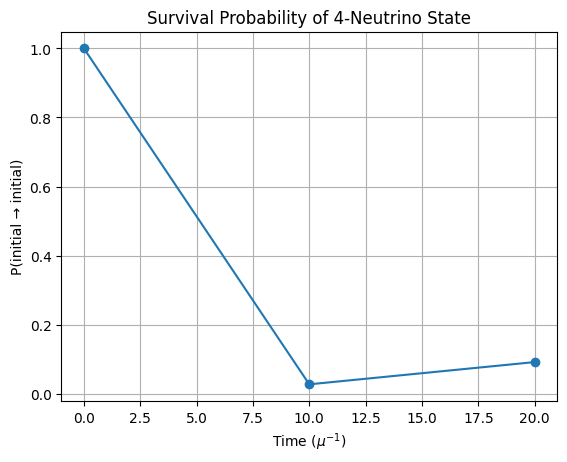

In [10]:
# Time loop setup for N neutrinos

pair_indices = [(i, j) for i in range(N) for j in range(i+1, N)]
dt = 10 / mu
T_max = 20 / mu
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

probabilities = []
shots = configs['shots']
for t in times:

    print("------------------------------")
    print("Time: ", t)
    print("Time step: ", dt)
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # Trotterization
    Trotter = int(t / dt)
    for _ in range(Trotter):
        pair_alphas = [(i, j, J_ij(i, j, E) * dt) for i, j in pair_indices]
        for i in range(N):
            qc.append(U1_omega_Omega(dt), [2*i, 2*i+1])

        apply_nunu_interaction(qc, pair_indices, pair_alphas)

    # Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")

    # convert our circuit to quimb circuit

    basis = [
        'cz', 'x', 'rz', 'sx'
    ]
    tqc = transpile(qc, basis_gates = basis, optimization_level = 3)
    # fig = tqc.draw('mpl')
    # from IPython.display import display
    # display(fig)

    tqc = qiskit_to_quimb(tqc, backend='torch')

    tn = tqc.psi

    optimizer = ctg.HyperOptimizer(
        methods = configs['methods'],
        max_repeats = configs['max_repeats'],
        slicing_reconf_opts = configs['slicing_reconf_opts'],
        max_time = configs['max_time'],
        progbar=True,
        parallel=True,
    )
    
    tn.contract(optimize=optimizer)

    gc.collect()

    counts = {}
    
    print("Beginning sampling...")

    for s in tqdm(tqc.sample(shots, seed = 42, backend='torch'), total=shots):
        if s in counts:
            counts[s] += 1
        else:
            counts[s] = 1

    # Target initial state pattern: 00 01 00 10 00 01 00 10 ...
    # Target initial state pattern based on same logic as initial state
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('01')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('10')  # nu_tau
        else:
            base_pattern.append('00')  # nu_e
    # Reverse the *pairs*, not individual bits
    target_state = ''.join((base_pattern))

    #print("Target state:", target_state)

    prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    probabilities.append(prob)

    gc.collect()

    current, peak = tracemalloc.get_traced_memory()
    print(f"Current memory usage: {current / 1024**2:.2f} MB; Peak: {peak / 1024**2:.2f} MB")



# Plot
plt.plot(times * mu, probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
plt.savefig("survi_prob_{0}_nu.png".format(N))

tracemalloc.stop()
